In [1]:
%load_ext autoreload
%autoreload 2

import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import esm
import sys
sys.path.insert(0,"../lib")
sys.path.insert(0,"/home/jovyan/workspace/unnotate/prophage/genev2")
from protein_embedder import embed_proteins
from ProteinEmbedding import ProteinEmbeddings
from IsolateDB import IsolateDB

from faiss_knn import FaissKNN
from collections import Counter
import torch

from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks, peak_widths


In [2]:
def detect_intervals(data, smooth_size, prominence, distance, rel_height):
    """
    Detect intervals in the data.
    Filters out intervals that are completely contained within larger intervals.
    """
    # Normalize data
    normalized = (data - data.min()) / (data.max() - data.min())
    # Smooth data
    smoothed = gaussian_filter1d(normalized, sigma=smooth_size)
    print(normalized)
    print(smoothed)
    # Find peaks
    peaks, props = find_peaks(smoothed, prominence=prominence, distance=distance)
    # Compute widths
    widths, heights, left_ips, right_ips = peak_widths(
        smoothed, peaks, rel_height=rel_height
    )
    # Create list of intervals
    intervals = list(zip(left_ips, right_ips))
    # Sort intervals by size (largest first) and start position
    intervals.sort(key=lambda x: (-(x[1] - x[0]), x[0]))
    # Filter out nested intervals
    filtered_intervals = []
    for interval in intervals:
        # Check if this interval is contained within any already accepted interval
        is_nested = False
        for accepted in filtered_intervals:
            if interval[0] >= accepted[0] and interval[1] <= accepted[1]:
                is_nested = True
                break
        if not is_nested:
            filtered_intervals.append(interval)
    # Sort by start position for display
    filtered_intervals.sort(key=lambda x: x[0])
    filtered_intervals = [(int(interval[0]), int(interval[1])) for interval in filtered_intervals]
    return filtered_intervals

In [3]:
protein_embeddings_path = "/home/jovyan/workspace/unnotate/data/protein_embeddings.h5"
uniprot_embeddings_path = "/home/jovyan/workspace/unnotate/data/embeddings.h5"
cluster_map_path = "/home/jovyan/workspace/unnotate/data/cluster_map.tsv"
db_path = "/home/jovyan/workspace/unnotate/data/isolate_db_full.sqlite"

In [4]:
with h5py.File(uniprot_embeddings_path, "r") as f:
    mean_data = f["mean"][...]
    max_data = f["max"][...]
    mean_mid_data = f["mean_middle_layer_12"][...]
    max_mid_data = f["max_middle_layer_12"][...]
    data_ids = f["indices"][...]
uniprot_embeddings = mean_mid_data

In [5]:
proteinEmbeddings = ProteinEmbeddings(
    embeddings_path=protein_embeddings_path,
    cluster_map_path=cluster_map_path
)

In [6]:
db = IsolateDB(db_path)
df_genome = db.get_genome_table()
df_virome = db.get_virome_table()

In [7]:
record_ids = db.get_all_record_ids()

In [8]:
knn = FaissKNN(dim=uniprot_embeddings.shape[1], metric="cosine", use_gpu=True)
knn.add(uniprot_embeddings)


In [9]:
all_protein_ids = []
all_protein_names = []
all_protein_embeddings = []
all_prophage_labels = []
all_record_ids = []
all_species_ids = []

for record_index in range(len(record_ids)):
    feat = db.get_record_feature(record_ids[record_index])

    protein_ids_raw = feat["protein_id"]
    protein_names_raw = feat["product"]
    prophage_label_raw = feat["prophage"]
    species = feat["species"][0]

    # Make sure all have same length before filtering
    if not (len(protein_ids_raw) == len(protein_names_raw) == len(prophage_label_raw)):
        print(
            f"[WARN] Length mismatch for record {record_ids[record_index]}: "
            f"ids({len(protein_ids_raw)}), names({len(protein_names_raw)}), "
            f"prophage({len(prophage_label_raw)})"
        )
        continue

    # Keep mask only based on protein_ids (truthy check)
    keep_mask = [bool(x) for x in protein_ids_raw]

    # Filter all lists using the same mask (aligned by index)
    protein_ids = [x for x, keep in zip(protein_ids_raw, keep_mask) if keep]
    protein_names = [x for x, keep in zip(protein_names_raw, keep_mask) if keep]
    prophage_label = [x for x, keep in zip(prophage_label_raw, keep_mask) if keep]

    print(record_index, len(protein_ids))

    if len(protein_ids) < 500:
        continue

    protein_embeddings = proteinEmbeddings.get_embeddings(protein_ids)

    all_protein_ids.append(protein_ids)
    all_protein_names.append(protein_names)
    all_protein_embeddings.append(protein_embeddings)
    all_prophage_labels.append(prophage_label)
    all_record_ids.append(record_ids[record_index])
    all_species_ids.append(species)


0 7375
1 6703
2 412
3 5503
4 2039
5 4162
6 86
7 52
8 3108
9 4851
10 242
11 197
12 99
13 106
14 49
15 5
16 5
17 3
18 4
19 1233
20 4852
21 2350
22 4908
23 1052
24 4359
25 123
26 4200
27 199
28 4046
29 4176
30 1657
31 2380
32 4266
33 2655
34 64
35 1507
36 1303
37 1471
38 386
39 60
40 46
41 54
42 24
43 3860
44 89
45 4144
46 505
47 291
48 702
49 500
50 1518
51 49
52 4822
53 9533
54 2807
55 2065
56 4237
57 53
58 4287
59 1696
60 1198
61 3585
62 2824
63 2580
64 2390
65 2520
66 3428
67 4097
68 1476
69 1277
70 842
71 4638
72 1058
73 1026
74 1028
75 2734
76 4226
77 1211
78 2830
79 838
80 3723
81 3674
82 4730
83 2723
84 4762
85 813
86 949
87 3083
88 4176
89 3812
90 1238
91 4915
92 3104
93 2649
94 1302
95 868
96 2573
97 995
98 2468
99 2556
100 3856
101 4105
102 3895
103 356
104 271
105 173
106 131
107 67
108 2332
109 2410
110 158
111 2655
112 7309
113 1944
114 1946
115 4414
116 101
117 3413
118 73
119 2538
120 28
121 6325
122 25
123 134
124 124
125 3378
126 2244
127 36
128 1165
129 2408
130 922
131

/home/jovyan/workspace/unnotate/prophage/genev2/IsolateDB.py:149: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['species_prev'] = df['species_prev'].fillna(0.)
/home/jovyan/workspace/unnotate/prophage/genev2/IsolateDB.py:150: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['homologs'] = df['homologs'].fillna(0.)


309 2124
310 62
311 2921
312 61
313 74
314 57
315 46
316 104
317 152
318 28
319 115
320 27
321 225
322 4
323 229
324 4
325 377
326 16
327 3
328 62
329 60
330 3
331 6
332 5869
333 89
334 9
335 5838
336 4134
337 60
338 25
339 3965
340 5
341 4146
342 2
343 14
344 137
345 45
346 5932
347 5180
348 213
349 469
350 1895
351 384
352 114
353 4525
354 3893
355 740
356 3743
357 4389
358 1967
359 28
360 31
361 30
362 4184
363 3276
364 2758
365 27
366 101
367 58
368 158
369 47
370 2742
371 5062
372 3778
373 3621
374 835
375 3213
376 5499
377 2148
378 3593
379 2511
380 94
381 2385
382 37
383 93
384 31
385 4533
386 2642
387 37
388 9
389 4076
390 236
391 172
392 316
393 504
394 692
395 3940
396 226
397 481
398 851
399 445
400 4011
401 984
402 138
403 130
404 80
405 1333
406 200
407 213
408 1323
409 1441
410 3942
411 186
412 83
413 103
414 3439
415 5669
416 2288
417 2267
418 2830
419 2549
420 163
421 1219
422 353
423 60
424 1628
425 3063
426 3585
427 3531
428 4392
429 3217
430 2276
431 63
432 4773
433 

In [10]:
len(all_protein_ids)

2138

In [549]:
record_prophage_map = dict(zip(all_record_ids, all_prophage_labels))
record_species_map = dict(zip(all_record_ids, all_species_ids))
record_product_map = dict(zip(all_record_ids, all_protein_names))
record_protein_embeddings_map = dict(zip(all_record_ids, all_protein_embeddings))
record_protein_id_map = dict(zip(all_record_ids, all_protein_ids))

In [12]:
len(all_prophage_labels)

2138

record_interval_map = {}
record_distance_map = {}
for index in range(len(all_species_ids)):
    print(index)
    distances, indices = knn.search(all_protein_embeddings[index], k=1)
    prophage_label = all_prophage_labels[index]
    protein_names = all_protein_names[index]
    intervals = detect_intervals(data=1-distances.flatten(),
                 smooth_size=20,
                 prominence=0.1,
                 distance=5,
                 rel_height=0.15)
    record_interval_map[all_record_ids[index]] = intervals
    record_distance_map[all_record_ids[index]] = distances

import pickle
with open("record_interval_map.pickle", "wb") as f:
    pickle.dump(record_interval_map, f)
with open("record_distance_map.pickle", "wb") as f:
    pickle.dump(record_distance_map, f)

In [14]:
import pickle
with open("record_interval_map.pickle", "rb") as f:
    record_interval_data = pickle.load(f)
with open("record_distance_map.pickle", "rb") as f:
    record_distance_data = pickle.load(f)

In [15]:
def check_overlap_prophage(prophage_val, interval):
    return sum(prophage_val[interval[0]: interval[1]]) > 0
    
all_summary_data = []
for record in all_record_ids:
    intervals = record_interval_data[record]
    prophage_vals = record_prophage_map[record]
    distances = record_distance_data[record].flatten()
    for interval in intervals:
        summary_data = {}
        summary_data["region_length"] = interval[1] - interval[0] + 1
        summary_data["region_mean"] = distances[interval[0]: interval[1] + 1].mean()
        summary_data["region_min"] = distances[interval[0]: interval[1] + 1].min()
        summary_data["region_max"] = distances[interval[0]: interval[1] + 1].max()
        summary_data["record_mean"] = distances.mean()
        summary_data["record_max"] = distances.max()
        summary_data["record_min"] = distances.min()
        summary_data["sample_id"] = record_species_map[record]
        summary_data["overlap_prophage"] = check_overlap_prophage(prophage_vals, interval)
        summary_data["mean_diff"] = summary_data["record_mean"] - summary_data["region_mean"] 
        summary_data["record_id"] = record
        summary_data["interval_start"] = interval[0]
        summary_data["interval_end"] = interval[1]

        all_summary_data.append(summary_data)

In [16]:
df_summary = pd.DataFrame(all_summary_data)

In [17]:
df_summary.head()

,region_length,region_mean,region_min,region_max,record_mean,record_max,record_min,sample_id,overlap_prophage,mean_diff,record_id,interval_start,interval_end
0,44,0.968230,0.900448,0.997319,0.977384,1.0,0.868696,GCA_004295565.1,False,0.009154,AP019416.1,1169,1212
1,73,0.968350,0.921127,0.998273,0.977384,1.0,0.868696,GCA_004295565.1,False,0.009034,AP019416.1,1996,2068
2,43,0.962171,0.868696,0.992811,0.977384,1.0,0.868696,GCA_004295565.1,True,0.015214,AP019416.1,3511,3553
3,46,0.963824,0.929810,0.996836,0.977384,1.0,0.868696,GCA_004295565.1,False,0.013560,AP019416.1,5385,5430
4,39,0.964775,0.933377,0.998273,0.974613,1.0,0.874863,GCA_007182875.1,False,0.009838,AP019514.1,1808,1846


In [18]:
selected_cols = ["record_id", "sample_id", "region_mean", "mean_diff", "interval_start", "interval_end"]
df_plot = df_summary[(df_summary.overlap_prophage == 0) & \
                        (df_summary.mean_diff > 0.01)].sort_values(["mean_diff", "region_mean", "sample_id"], ascending = False)[selected_cols]

In [19]:
import torch
import torch.nn.functional as F

@torch.inference_mode(False)
def pairwise_cosine(
    x: torch.Tensor,
    y: torch.Tensor | None = None,
    eps: float = 1e-8,
    chunk_size: int | None = None,
) -> torch.Tensor:
    """
    Compute pairwise cosine similarity between rows of x and y.

    Args:
        x: (N, D) tensor.
        y: (M, D) tensor. If None, uses y = x (returns (N, N)).
        eps: Numerical stability for normalization.
        chunk_size: If provided, compute in blocks of this many rows from x to
                    reduce peak memory (useful for very large N or M).

    Returns:
        sim: (N, M) tensor where sim[i, j] = cosine(x[i], y[j]).
    """
    if x.dim() != 2:
        raise ValueError(f"x must be 2D (N, D), got {x.shape}")
    if y is None:
        y = x
    if y.dim() != 2:
        raise ValueError(f"y must be 2D (M, D), got {y.shape}")
    if x.size(1) != y.size(1):
        raise ValueError(f"Feature dims must match: {x.size(1)} vs {y.size(1)}")

    # Normalize rows (keeps dtype/device; autograd-friendly)
    x_n = F.normalize(x, p=2, dim=1, eps=eps)
    y_n = F.normalize(y, p=2, dim=1, eps=eps)

    # Fast path: single matmul
    if chunk_size is None:
        return x_n @ y_n.t()

    # Chunked path: reduce memory by processing x in blocks
    N = x_n.size(0)
    M = y_n.size(0)
    out = x_n.new_empty((N, M))  # same dtype/device as inputs
    for start in range(0, N, chunk_size):
        end = min(start + chunk_size, N)
        out[start:end] = x_n[start:end] @ y_n.t()
    return out

In [21]:
selected_record_index = "NZ_CP090369.1"

test_mat1 = record_protein_embeddings_map[selected_record_index][:100]
test_mat2 = record_protein_embeddings_map[selected_record_index][300:400]

In [22]:
pairwise_cosine(torch.Tensor(test_mat2).to("cuda"), torch.Tensor(test_mat1).to("cuda")).max(dim = 1)[0].mean()

tensor(0.9700, device='cuda:0')

In [58]:
sim_mat = pairwise_cosine(torch.Tensor(record_protein_embeddings_map[selected_record_index]).to("cuda"),\
                torch.Tensor(record_protein_embeddings_map[selected_record_index]).to("cuda"))#.max(dim = 1)[0].mean()

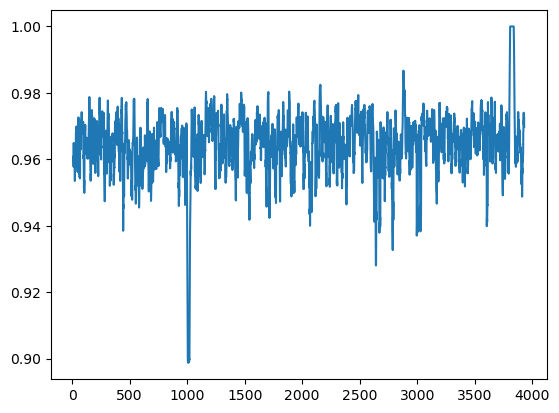

In [59]:
plt.plot(pd.Series(sim_mat.detach().cpu().numpy()[3799:3840].max(axis=0)).rolling(window=10).mean())

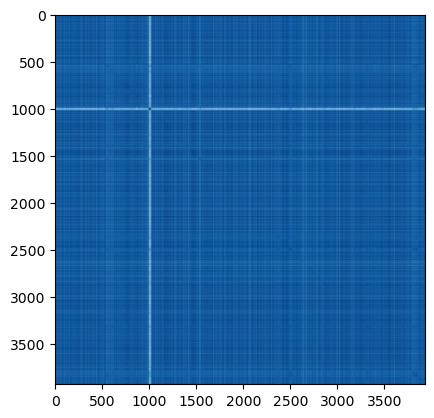

In [60]:
plt.imshow(sim_mat.detach().cpu().numpy(),cmap = "Blues")

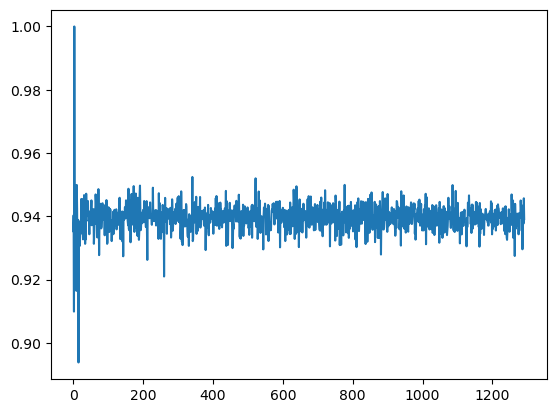

In [89]:
plt.plot(similarity)

In [94]:
all_similarity = []
df_plot = df_plot.reset_index()
for anchor_index, anchor_row in df_plot.iterrows():
    selected_embeddings = record_protein_embeddings_map[anchor_row["record_id"]][anchor_row["interval_start"]: anchor_row["interval_end"]+1]
    similarity = []
    print(anchor_index)
    for index, row in df_plot.iterrows():
        start = row["interval_start"]
        end = row["interval_end"]
        embeddings = record_protein_embeddings_map[row["record_id"]][start: end+1]
        sim_mat = pairwise_cosine(torch.Tensor(selected_embeddings).to("cuda"),\
                    torch.Tensor(embeddings).to("cuda"))
        similarity.append(sim_mat.max(axis = 1)[0].mean().item())
    all_similarity.append(similarity)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [100]:
import torch
import torch.nn.functional as F

def build_gpu_records(record_protein_embeddings_map, device="cuda", dtype=torch.float16, eps=1e-8):
    """
    Convert each record's embeddings to a single normalized GPU tensor.
    record_protein_embeddings_map[record_id] -> array-like of shape (L, D)
    """
    gpu_records = {}
    for rid, arr in record_protein_embeddings_map.items():
        t = torch.as_tensor(arr, device=device, dtype=dtype)
        t = F.normalize(t, p=2, dim=1, eps=eps)  # row-wise L2 (cosine-ready)
        gpu_records[rid] = t.contiguous()
    return gpu_records

@torch.inference_mode()
def fast_window_similarity(df_plot, gpu_records, batch_j: int = 64):
    """
    For each anchor window A, compute similarity to every target window B:
        score(A,B) = mean(max_j (A @ B^T)_row )  i.e., per-row maxima then mean.

    Args:
      df_plot: DataFrame with columns ["record_id", "interval_start", "interval_end"]
      gpu_records: dict[record_id] -> (L, D) normalized torch.Tensor on GPU
      batch_j: process target windows in chunks to reduce Python overhead

    Returns:
      all_similarity: list of lists (N x N) of floats
    """
    # compact rows
    rows = list(zip(
        df_plot["record_id"].to_list(),
        df_plot["interval_start"].to_list(),
        df_plot["interval_end"].to_list()
    ))
    N = len(rows)
    all_similarity = [[0.0]*N for _ in range(N)]

    for i, (rid_a, sa, ea) in enumerate(rows):
        Xa = gpu_records[rid_a][sa:ea+1]           # (Na, D), already normalized

        # inner loop, optionally batched to amortize overhead
        j = 0
        while j < N:
            jb = min(j + batch_j, N)
            # Process each target in this batch. (Different lengths → can’t stack neatly.)
            for k in range(j, jb):
                rid_b, sb, eb = rows[k]
                Yb = gpu_records[rid_b][sb:eb+1]   # (Nb, D), normalized
                # cosine = Xa @ Yb^T
                sim = Xa @ Yb.T                    # (Na, Nb)
                # reduce: per-row max over B, then mean over rows
                score = sim.max(dim=1).values.mean().item()
                all_similarity[i][k] = score
            j = jb

    return all_similarity

# -------------------------- Usage --------------------------
# 1) Reset index once (cheap)
# df_plot = df_plot.reset_index(drop=True)

# 2) Prepare GPU tensors once
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype  = torch.float16 if (device == "cuda") else torch.float32  # FP16 on GPU for speed
gpu_records = build_gpu_records(record_protein_embeddings_map, device=device, dtype=dtype)

# 3) Run (tune batch_j for your GPU/CPU)
all_similarity_fast = fast_window_similarity(df_plot, gpu_records, batch_j=64)


In [107]:
all_similarity[0][:10]

[1.0000001192092896,
 0.9233669638633728,
 0.8483343124389648,
 0.9203043580055237,
 0.9307450652122498,
 0.9144416451454163,
 0.9097539186477661,
 0.9155836701393127,
 0.9194548726081848,
 0.9172441959381104]

In [126]:
all_similarity_fast[-1][-1]

1.0

In [146]:
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

# --- Prep similarity matrix ---
S = np.asarray(all_similarity, dtype=np.float64)
S = 0.5 * (S + S.T)   # symmetrize
np.fill_diagonal(S, 1.0)
S = np.clip(S, 0.0, 1.0)

# --- Convert to distance ---
D = 1.0 - S
Dc = squareform(D, checks=False)

# --- Hierarchical clustering (average linkage works well here) ---
Z = linkage(Dc, method="average")

# --- Cut at distance threshold (0.05 -> sim >= 0.95) ---
labels = fcluster(Z, t=0.03, criterion="distance")


,index,record_id,sample_id,region_mean,mean_diff,interval_start,interval_end
24,1623,NZ_CP080599.1,GCF_019598965.1,0.966474,0.022053,2257,2291
27,1429,NZ_CP074133.1,GCF_018316655.1,0.966841,0.021697,413,444


In [147]:
def cluster_avg_sim(S, labels):
    out = {}
    for lab in np.unique(labels):
        idx = np.where(labels == lab)[0]
        if len(idx) < 2:
            out[lab] = 1.0  # singletons -> trivially similar
        else:
            sub = S[np.ix_(idx, idx)]
            avg = (sub.sum() - len(idx)) / (len(idx)*(len(idx)-1))
            out[lab] = avg
    return out

avg_sims = cluster_avg_sim(S, labels)
for lab, sim in avg_sims.items():
    print(f"Cluster {lab}: average similarity={sim:.3f}")


Cluster 1: average similarity=1.000
Cluster 2: average similarity=1.000
Cluster 3: average similarity=1.000
Cluster 4: average similarity=1.000
Cluster 5: average similarity=1.000
Cluster 6: average similarity=1.000
Cluster 7: average similarity=1.000
Cluster 8: average similarity=1.000
Cluster 9: average similarity=1.000
Cluster 10: average similarity=1.000
Cluster 11: average similarity=1.000
Cluster 12: average similarity=1.000
Cluster 13: average similarity=1.000
Cluster 14: average similarity=1.000
Cluster 15: average similarity=1.000
Cluster 16: average similarity=1.000
Cluster 17: average similarity=1.000
Cluster 18: average similarity=1.000
Cluster 19: average similarity=1.000
Cluster 20: average similarity=1.000
Cluster 21: average similarity=1.000
Cluster 22: average similarity=1.000
Cluster 23: average similarity=1.000
Cluster 24: average similarity=1.000
Cluster 25: average similarity=1.000
Cluster 26: average similarity=1.000
Cluster 27: average similarity=1.000
Cluster 28

In [501]:
df_plot

,index,record_id,sample_id,region_mean,mean_diff,interval_start,interval_end
0,1909,NZ_CP090369.1,GCF_021431905.1,0.948517,0.040271,990,1019
1,846,NZ_CP040281.1,GCF_013393925.1,0.951048,0.035006,1281,1331
2,1240,NZ_CP063353.1,GCF_014931565.1,0.958044,0.031207,1866,1893
3,3298,NZ_CP132380.1,GCF_030758595.1,0.962344,0.028465,1642,1685
4,1321,NZ_CP067432.1,GCF_016657085.1,0.959963,0.028196,2124,2149
...,...,...,...,...,...,...,...
1287,953,NZ_CP046120.1,GCF_009707465.1,0.978320,0.010025,3007,3039
1288,643,NZ_AP027939.1,GCF_037076395.1,0.981965,0.010016,3008,3042
1289,558,CP170752.1,GCA_043099345.1,0.972995,0.010013,833,866
1290,2324,NZ_CP103098.1,GCF_024759125.1,0.978732,0.010013,1044,1085


In [506]:
df_plot[df_plot.sample_id == "GCF_009493695.2"]

,index,record_id,sample_id,region_mean,mean_diff,interval_start,interval_end
12,3793,NZ_CP143309.1,GCF_009493695.2,0.958535,0.024495,1002,1037
13,3795,NZ_CP143309.1,GCF_009493695.2,0.958887,0.024143,1860,1895
16,3796,NZ_CP143309.1,GCF_009493695.2,0.959701,0.023330,2000,2027
60,3792,NZ_CP143309.1,GCF_009493695.2,0.963644,0.019386,58,83


In [509]:
df_bacterial_taxa.columns

Index(['species', 'family', 'order', 'class', 'phylum', 'kingdom', 'genus',
       'accession'],
      dtype='object')

In [510]:
df_bacterial_taxa[df_bacterial_taxa.accession == "GCF_009493695.2"]

,species,family,order,class,phylum,kingdom,genus,accession
1193,"('59779', 'Paracoccus marcusii')","('31989', 'Paracoccaceae')","('204455', 'Rhodobacterales')","('28211', 'Alphaproteobacteria')","('1224', 'Pseudomonadota')","('3379134', 'Pseudomonadati')","('265', 'Paracoccus')",GCF_009493695.2


In [647]:
cblaster_path = "/home/jovyan/workspace/unnotate/cblaster_outs/cblaster__NZ_CP090369.1.NCBI.binary.tsv"
pd.read_csv(cblaster_path, sep = " ")

ParserError: Error tokenizing data. C error: Expected 363 fields in line 3, saw 364


In [507]:
df_plot.iloc[:20]

,index,record_id,sample_id,region_mean,mean_diff,interval_start,interval_end
0,1909,NZ_CP090369.1,GCF_021431905.1,0.948517,0.040271,990,1019
1,846,NZ_CP040281.1,GCF_013393925.1,0.951048,0.035006,1281,1331
2,1240,NZ_CP063353.1,GCF_014931565.1,0.958044,0.031207,1866,1893
3,3298,NZ_CP132380.1,GCF_030758595.1,0.962344,0.028465,1642,1685
4,1321,NZ_CP067432.1,GCF_016657085.1,0.959963,0.028196,2124,2149
5,25,AP031461.1,GCA_040361705.1,0.959154,0.027893,2472,2504
6,4731,NZ_OZ075067.1,GCF_964186585.1,0.962585,0.027199,317,343
7,4687,NZ_OY979223.1,GCF_963855525.1,0.964284,0.026053,3307,3335
8,4093,NZ_CP159479.1,GCF_042140225.1,0.965777,0.025256,1588,1612
9,90,CP064967.1,GCA_016699265.1,0.958872,0.025247,89,110


In [502]:
df_plot.sort_values("region_mean").iloc[:10]

,index,record_id,sample_id,region_mean,mean_diff,interval_start,interval_end
19,224,CP096171.1,GCA_023374955.1,0.946569,0.022880,381,406
0,1909,NZ_CP090369.1,GCF_021431905.1,0.948517,0.040271,990,1019
1,846,NZ_CP040281.1,GCF_013393925.1,0.951048,0.035006,1281,1331
69,367,CP126971.1,GCA_030252205.1,0.956297,0.019068,1737,1772
422,29,CP025776.1,GCA_002886105.1,0.956762,0.013864,553,593
98,366,CP126971.1,GCA_030252205.1,0.957236,0.018130,599,635
212,1866,NZ_CP087968.1,GCF_024703895.1,0.957437,0.015850,2300,2332
2,1240,NZ_CP063353.1,GCF_014931565.1,0.958044,0.031207,1866,1893
12,3793,NZ_CP143309.1,GCF_009493695.2,0.958535,0.024495,1002,1037
9,90,CP064967.1,GCA_016699265.1,0.958872,0.025247,89,110


In [396]:
df_plot.iloc[122]

index                        1703
record_id           NZ_CP082772.1
sample_id         GCF_021399015.1
region_mean               0.97541
mean_diff                0.017543
interval_start                493
interval_end                  527
Name: 122, dtype: object

In [408]:
df_bacterial_taxa = pd.read_csv("../data/bacterial_taxa.csv")
df_bacterial_taxa

,species,family,order,class,phylum,kingdom,genus,accession
0,"('592317', '[Empedobacter] haloabium')","('75682', 'Oxalobacteraceae')","('80840', 'Burkholderiales')","('28216', 'Betaproteobacteria')","('1224', 'Pseudomonadota')","('3379134', 'Pseudomonadati')",NaN,GCA_008011715.2
1,"('1324864', '[Pantoea] beijingensis')","('1903409', 'Erwiniaceae')","('91347', 'Enterobacterales')","('1236', 'Gammaproteobacteria')","('1224', 'Pseudomonadota')","('3379134', 'Pseudomonadati')","('551', 'Erwinia')",GCF_022647505.1
2,"('33039', '[Ruminococcus] torques')","('186803', 'Lachnospiraceae')","('3085636', 'Lachnospirales')","('186801', 'Clostridia')","('1239', 'Bacillota')","('1783272', 'Bacillati')","('2316020', 'Mediterraneibacter')",GCF_044591705.1
3,"('3157919', 'Acerihabitans sp. KWT182')","('1903410', 'Pectobacteriaceae')","('91347', 'Enterobacterales')","('1236', 'Gammaproteobacteria')","('1224', 'Pseudomonadota')","('3379134', 'Pseudomonadati')","('2811373', 'Acerihabitans')",GCA_040208185.1
4,"('52694', 'Acetobacterium wieringae')","('186806', 'Eubacteriaceae')","('186802', 'Eubacteriales')","('186801', 'Clostridia')","('1239', 'Bacillota')","('1783272', 'Bacillati')","('33951', 'Acetobacterium')",GCF_023700225.1
...,...,...,...,...,...,...,...,...
1953,"('3137369', 'Yoonia phaeophyticola')","('31989', 'Paracoccaceae')","('204455', 'Rhodobacterales')","('28211', 'Alphaproteobacteria')","('1224', 'Pseudomonadota')","('3379134', 'Pseudomonadati')","('2211641', 'Yoonia')",GCF_038069655.2
1954,"('3137370', 'Yoonia rhodophyticola')","('31989', 'Paracoccaceae')","('204455', 'Rhodobacterales')","('28211', 'Alphaproteobacteria')","('1224', 'Pseudomonadota')","('3379134', 'Pseudomonadati')","('2211641', 'Yoonia')",GCF_038443705.2
1955,"('3093869', 'Yoonia sp. R78084')","('31989', 'Paracoccaceae')","('204455', 'Rhodobacterales')","('28211', 'Alphaproteobacteria')","('1224', 'Pseudomonadota')","('3379134', 'Pseudomonadati')","('2211641', 'Yoonia')",GCF_044595625.1
1956,"('2528593', 'Zhaonella formicivorans')","('2748673', 'Zhaonellaceae')","('3039167', 'Neomorellales')","('186801', 'Clostridia')","('1239', 'Bacillota')","('1783272', 'Bacillati')","('2748674', 'Zhaonella')",GCF_004353525.1


In [199]:
for i, row in df_plot.iloc[clusters[372]].iterrows():
    record_id = row["record_id"]
    start = row["interval_start"]
    end = row["interval_end"]
    print(record_product_map[record_id][start:end+1])
    print(row["sample_id"])
    print()

['cysteine--1-D-myo-inosityl 2-amino-2-deoxy-alpha-D-glucopyranoside ligase', 'hypothetical protein', 'hypothetical protein', 'siderophore-interacting protein', 'glycoside hydrolase family 16 protein', 'MFS transporter', 'PLP-dependent aminotransferase family protein', 'DMT family transporter', 'WD40 repeat domain-containing serine/threonine protein kinase', 'WD40 repeat domain-containing serine/threonine protein kinase', 'hypothetical protein', 'hypothetical protein', 'DUF397 domain-containing protein', 'DUF397 domain-containing protein', 'DUF397 domain-containing protein', 'DUF397 domain-containing protein', 'DUF397 domain-containing protein', 'helix-turn-helix transcriptional regulator', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'MerR family transcriptional regulator', 'NADP-dependent oxidoreductase', 'MarR family winged helix-turn-helix transcriptional regulator', 'nuclear transport factor 2 family protein', 'VOC family protein'

In [761]:
for i, row in df_plot.iloc[clusters[270]].iterrows():
    interval = (row["interval_start"], row["interval_end"])
    print("Interval length:", interval[1] - interval[0])
    print(record_product_map[row["record_id"]][interval[0]: interval[1]])
    print(record_interval_data[row["record_id"]])

Interval length: 35
['isovaleryl-CoA dehydrogenase', 'AraC family transcriptional regulator', 'DUF3551 domain-containing protein', 'Lrp/AsnC family transcriptional regulator', 'ETC complex I subunit', 'OpgC domain-containing protein', 'translational machinery protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'DUF192 domain-containing protein', 'cold-shock protein', 'SIR2 family NAD-dependent protein deacylase', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'HU family DNA-binding protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'DUF3072 domain-containing protein', 'hypothetical protein', 'hypothetical protein', 'oxidoreductase', 'tannase/feruloyl esterase family alpha/beta hydrolase', 'hypothetical protein', 'VOC family protein', 'glutathione S-transferase family protein', 'hypot

In [563]:
df_plot.columns

Index(['index', 'record_id', 'sample_id', 'region_mean', 'mean_diff',
       'interval_start', 'interval_end'],
      dtype='object')

In [571]:
df_merged = pd.merge(df_plot, df_bacterial_taxa, left_on="sample_id", right_on="accession")

In [579]:
df_merged.columns

Index(['index', 'record_id', 'sample_id', 'region_mean', 'mean_diff',
       'interval_start', 'interval_end', 'species', 'family', 'order', 'class',
       'phylum', 'kingdom', 'genus', 'accession'],
      dtype='object')

In [628]:
import numpy as np
from collections import defaultdict

def cluster_indices(labels):
    """
    Given a 1D array of cluster labels, return a dict: cluster_id -> list of indices,
    sorted by cluster size (largest first).
    """
    clusters = defaultdict(list)
    for idx, lab in enumerate(labels):
        clusters[lab].append(idx)

    # sort by cluster size (descending)
    sorted_clusters = dict(
        sorted(clusters.items(), key=lambda x: len(x[1]), reverse=True)
    )
    return sorted_clusters

# Example
clusters = cluster_indices(labels)

for cid, idxs in clusters.items():
    print(f"Cluster {cid} (size={len(idxs)}): indices={idxs}")
    print("Mean mean diff = ", df_plot.iloc[idxs].mean_diff.mean())
    print("[TAXA]: Class", df_merged.iloc[idxs]["class"].value_counts())
    print("[TAXA]: Order", df_merged.iloc[idxs]["order"].value_counts())
    print("[TAXA]: Family", df_merged.iloc[idxs]["family"].value_counts())
    print("[TAXA]: Genus", df_merged.iloc[idxs]["genus"].value_counts())
    print("[TAXA]: Species", df_merged.iloc[idxs]["species"].value_counts())
    print("ID", df_merged.iloc[idxs]["sample_id"].tolist())

    print()

Cluster 737 (size=60): indices=[122, 138, 140, 199, 230, 264, 288, 387, 388, 398, 470, 500, 514, 547, 598, 626, 635, 665, 684, 686, 687, 700, 705, 712, 724, 746, 773, 885, 899, 932, 940, 943, 944, 949, 965, 983, 997, 1014, 1022, 1023, 1041, 1045, 1072, 1094, 1099, 1115, 1120, 1129, 1133, 1136, 1162, 1177, 1183, 1186, 1187, 1190, 1193, 1218, 1243, 1257]
Mean mean diff =  0.012109157
[TAXA]: Class class
('1236', 'Gammaproteobacteria')    56
('28216', 'Betaproteobacteria')     4
Name: count, dtype: int64
[TAXA]: Order order
('91347', 'Enterobacterales')      27
('72274', 'Pseudomonadales')       21
('135625', 'Pasteurellales')        4
('80840', 'Burkholderiales')        4
('135619', 'Oceanospirillales')     3
('135614', 'Lysobacterales')        1
Name: count, dtype: int64
[TAXA]: Family family
('135621', 'Pseudomonadaceae')      21
('543', 'Enterobacteriaceae')       13
('1903411', 'Yersiniaceae')          5
('1903410', 'Pectobacteriaceae')     5
('712', 'Pasteurellaceae')           4
('

In [ ]:
df_genome[df_genome.record_id == "NZ_CP132380.1"].iloc[1642+100: 1685+101]["start"].to_list()

In [479]:
df_plot[:20]

,index,record_id,sample_id,region_mean,mean_diff,interval_start,interval_end
0,1909,NZ_CP090369.1,GCF_021431905.1,0.948517,0.040271,990,1019
1,846,NZ_CP040281.1,GCF_013393925.1,0.951048,0.035006,1281,1331
2,1240,NZ_CP063353.1,GCF_014931565.1,0.958044,0.031207,1866,1893
3,3298,NZ_CP132380.1,GCF_030758595.1,0.962344,0.028465,1642,1685
4,1321,NZ_CP067432.1,GCF_016657085.1,0.959963,0.028196,2124,2149
5,25,AP031461.1,GCA_040361705.1,0.959154,0.027893,2472,2504
6,4731,NZ_OZ075067.1,GCF_964186585.1,0.962585,0.027199,317,343
7,4687,NZ_OY979223.1,GCF_963855525.1,0.964284,0.026053,3307,3335
8,4093,NZ_CP159479.1,GCF_042140225.1,0.965777,0.025256,1588,1612
9,90,CP064967.1,GCA_016699265.1,0.958872,0.025247,89,110


In [ ]:
1_100_491 - 1_117_000

In [ ]:
df_genome[df_genome.record_id == "NZ_CP090369.1"].iloc[550: 650]["product"].to_list()

In [ ]:
2072128 - 2092861

In [ ]:
81195 - 110765

In [ ]:
# df_genome[df_genome.record_id == "NZ_CP159479.1"].iloc[1655: 1680]["product"].to_list()
df_genome[df_genome.record_id == "NZ_CP082772.1"].iloc[540: 580]["start"].to_list()

In [454]:
df_new_strain = pd.read_csv("/home/jovyan/workspace/unnotate/out4/GCF_034509165.1_cosine_similarity.csv")

<Axes: >

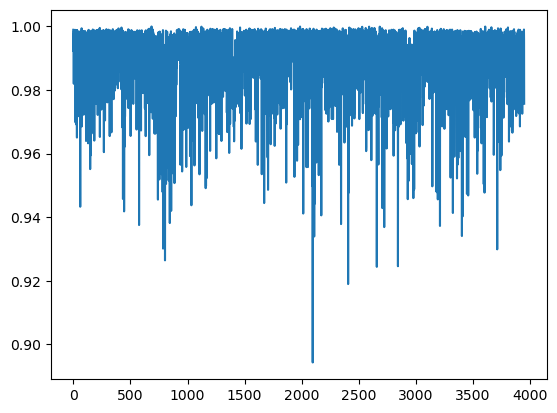

In [455]:
df_new_strain.neighbor_1.plot()

In [432]:
import Bio
from Bio.Seq import Seq
from Bio import SeqIO

In [457]:
descriptions = []
for record in SeqIO.parse("../data/GCF_034509165.1_ASM3450916v1_translated_cds.faa", "fasta"):
    descriptions.append(record.description)

In [ ]:
descriptions[750:950]

In [448]:
1012429/1000

1012.429

In [447]:
3237308 - 4249737

-1012429

<Axes: >

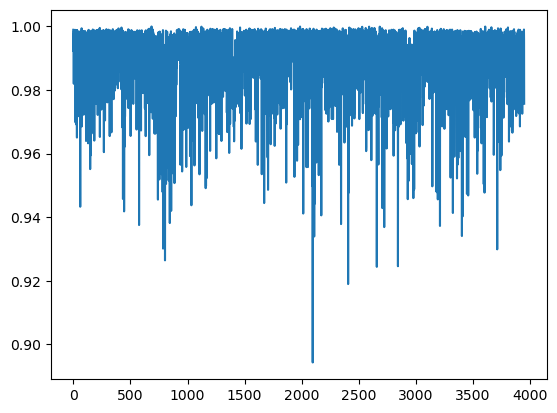

In [462]:
df_new_strain.neighbor_1.rolling(window=1).mean().plot()

In [737]:
df_plot.iloc[:20]

,index,record_id,sample_id,region_mean,mean_diff,interval_start,interval_end
0,1909,NZ_CP090369.1,GCF_021431905.1,0.948517,0.040271,990,1019
1,846,NZ_CP040281.1,GCF_013393925.1,0.951048,0.035006,1281,1331
2,1240,NZ_CP063353.1,GCF_014931565.1,0.958044,0.031207,1866,1893
3,3298,NZ_CP132380.1,GCF_030758595.1,0.962344,0.028465,1642,1685
4,1321,NZ_CP067432.1,GCF_016657085.1,0.959963,0.028196,2124,2149
5,25,AP031461.1,GCA_040361705.1,0.959154,0.027893,2472,2504
6,4731,NZ_OZ075067.1,GCF_964186585.1,0.962585,0.027199,317,343
7,4687,NZ_OY979223.1,GCF_963855525.1,0.964284,0.026053,3307,3335
8,4093,NZ_CP159479.1,GCF_042140225.1,0.965777,0.025256,1588,1612
9,90,CP064967.1,GCA_016699265.1,0.958872,0.025247,89,110


In [735]:
df_plot.sort_values("region_mean").iloc[:20]

,index,record_id,sample_id,region_mean,mean_diff,interval_start,interval_end
19,224,CP096171.1,GCA_023374955.1,0.946569,0.022880,381,406
0,1909,NZ_CP090369.1,GCF_021431905.1,0.948517,0.040271,990,1019
1,846,NZ_CP040281.1,GCF_013393925.1,0.951048,0.035006,1281,1331
69,367,CP126971.1,GCA_030252205.1,0.956297,0.019068,1737,1772
422,29,CP025776.1,GCA_002886105.1,0.956762,0.013864,553,593
98,366,CP126971.1,GCA_030252205.1,0.957236,0.018130,599,635
212,1866,NZ_CP087968.1,GCF_024703895.1,0.957437,0.015850,2300,2332
2,1240,NZ_CP063353.1,GCF_014931565.1,0.958044,0.031207,1866,1893
12,3793,NZ_CP143309.1,GCF_009493695.2,0.958535,0.024495,1002,1037
9,90,CP064967.1,GCA_016699265.1,0.958872,0.025247,89,110


In [754]:
selected_protein_ids = record_protein_id_map["AP031461.1"][2472:2504]

In [755]:
record_product_map["AP031461.1"][2472:2504]

['VF530 family DNA-binding protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein',
 'hypothetical protein']

In [582]:
df_all_proteins = pd.read_csv("../data/all_proteins.csv")

In [585]:
df_all_proteins.head()

,ID,Sequence
0,UVP48655.1,MKKHILLTCVSLLVSLLSISASIEVRSTHMTTTDGLANNSICYIFQ...
1,UVP48656.1,MKREAFKMFLKSGYEKEYERRHAAIWPELKKMLSDGGVYDYSIYWD...
2,UVP48657.1,MNIKTLCLTGALLLTGISIYAQKKKEVINDSNTPLHLLQPAYKVPY...
3,UVP48658.1,MKKPSLKFLISIAAITVISIGVSGALTAPRYKIAANAPAYDYSKLQ...
4,UVP48659.1,MKHLFSIFLLTFLWTSLHAAASESRDKYNFNSDWLLSVGDKSGAEK...


In [597]:
import pandas as pd

def csv_to_fasta(df, fasta_file, id_col=1, seq_col=2, sep="\t"):
    with open(fasta_file, "w") as f:
        for _, row in df.iterrows():
            seq_id = str(row[id_col])
            seq = str(row[seq_col])
            f.write(f">{seq_id}\n{seq}\n")

# Example usage:
# csv_to_fasta("proteins.csv", "proteins.fasta", id_col=1, seq_col=2, sep="\t")


In [756]:
df_selected = df_all_proteins[df_all_proteins.ID.isin(selected_protein_ids)].reset_index()

In [757]:
df_selected

,index,ID,Sequence
0,4106961,BFL84023.1,MITELVDFYSWKILFAALKLGCFNTNPTIEASVIFPQKTEWAREKV...
1,4106962,BFL84024.1,MEIEQARRTQINHRKGLERVLEATSGLFELRTLHKFADGLLTQVAT...
2,4106963,BFL84025.1,MKVLVVDDEPDVHTVTKLALSRFKLDGRALTFINAYSAEQAKELLN...
3,4106964,BFL84026.1,MAILSSFYSYLTSEEYCERNPAQIWLNHSRFAANRQYQRQSHEEEN...
4,4106965,BFL84027.1,MAISKALLDALVKYRQFLGLADYPAPNENHPLFVRHKAAGRGRDAG...
5,4106966,BFL84028.1,MYHADSPTHEIFQYDFDPNTASVSNKRSFVTTEQMIFPDGSEVDAA...
6,4106967,BFL84029.1,MIKPNPFGGLILKLLRYSITTQSLRTIAMPYRVGSFGLTQNAEQLI...
7,4106968,BFL84030.1,MVSVEEEPVVLEIDVSGMAKYLRWEERTEEPLGTWPNLYVEGVPVE...
8,4106969,BFL84031.1,MEQNIDEDIEAVENLFSQLSIYCNEVELSNGFCPQIIVTDHADNLT...
9,4106970,BFL84032.1,MKAKFESSLVDVQRNIEVFDKELTALNQQITEIEKTEKQLAELKSL...


In [746]:
csv_to_fasta(df_selected.iloc[4:], 
             "../data/interesting_region_CP096171.1.NCBI.proteins.faa")

/tmp/ipykernel_575391/2964036832.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  seq_id = str(row[id_col])
/tmp/ipykernel_575391/2964036832.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  seq = str(row[seq_col])


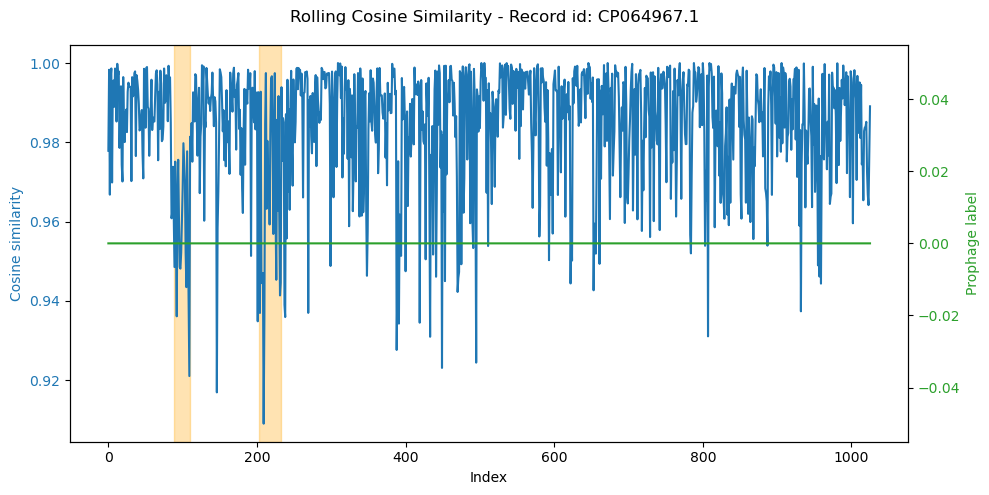

Interval length: 21
['hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein']
Interval length: 30
['peptidoglycan bridge formation glycyltransferase FemA/FemB family protein', 'hypothetical protein', 'DegT/DnrJ/EryC1/StrS aminotransferase family protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'hypothetical protein', 'transcriptional repressor', 'hypothetical protein', 'ZIP family metal transporter', 'hypothetical protein', 'hypothetical protein', 'efflux RND transpor

In [753]:
selected_record_index = "CP064967.1"
visualize(selected_record_index)

for interval in record_interval_data[selected_record_index]:
    print("Interval length:", interval[1] - interval[0])
    print(record_product_map[selected_record_index][interval[0]: interval[1]])
print(record_interval_data[selected_record_index])

In [387]:
df_summary.columns

Index(['region_length', 'region_mean', 'region_min', 'region_max',
       'record_mean', 'record_max', 'record_min', 'sample_id',
       'overlap_prophage', 'mean_diff', 'record_id', 'interval_start',
       'interval_end'],
      dtype='object')

<Axes: xlabel='mean_diff', ylabel='Count'>

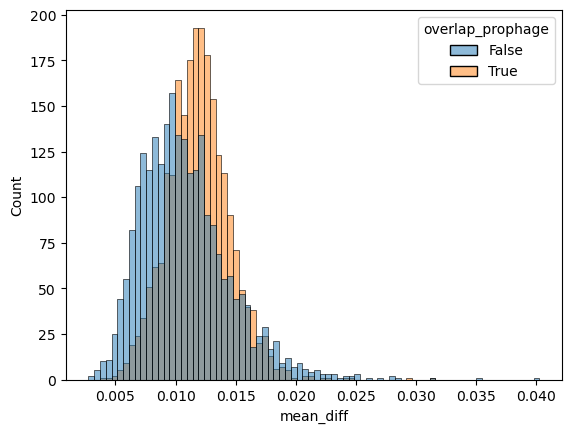

In [390]:
sns.histplot(data = df_summary, x = "mean_diff", hue = "overlap_prophage")

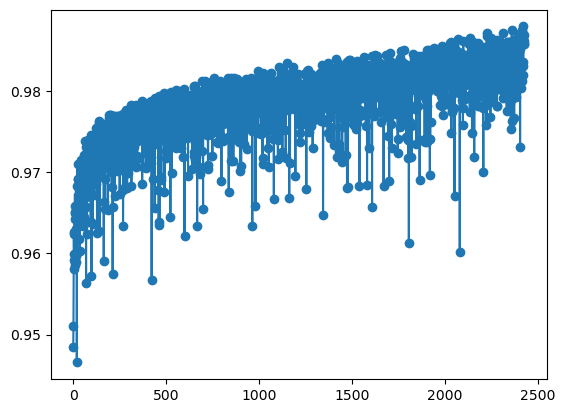

In [386]:
plt.plot(df_plot["region_mean"].values, marker = "o")

intervals = detect_intervals(data=1-distances.flatten(),
                 smooth_size=20,
                 prominence=0.1,
                 distance=5,
                 rel_height=0.15)
for interval in intervals:
    print("Interval length:", interval[1] - interval[0])
    print(protein_names[interval[0]: interval[1]])
print(intervals)

In [536]:
import matplotlib.pyplot as plt
import pandas as pd

def visualize(record_id):
    # Example data
    rolling_series = pd.Series(record_distance_data[record_id].flatten()).rolling(window=1, center=True).mean()
    
    # Create figure and first axis
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    # Plot first series (left y-axis)
    color1 = 'tab:blue'
    ax1.set_xlabel("Index")
    ax1.set_ylabel("Cosine similarity", color=color1)
    ax1.plot(rolling_series, color=color1, label='1 - distances (smoothed)')
    ax1.tick_params(axis='y', labelcolor=color1)
    
    # Create second y-axis
    ax2 = ax1.twinx()
    color2 = 'tab:green'
    ax2.set_ylabel("Prophage label", color=color2)
    ax2.plot(record_prophage_map[record_id], color=color2, label='Prophage label')
    ax2.tick_params(axis='y', labelcolor=color2)
    
    # Plot shaded bands on both axes
    for start, end in record_interval_data[record_id]:
        ax1.axvspan(start, end, color='orange', alpha=0.3)
    
    # Add title and layout
    fig.suptitle(f"Rolling Cosine Similarity - Record id: {record_id}")
    fig.tight_layout()
    plt.show()


In [ ]:
1507132 - 1560000

In [ ]:
GCF_021431905.1

In [416]:
df_bacterial_taxa[df_bacterial_taxa.accession == "GCF_021431905.1"]

,species,family,order,class,phylum,kingdom,genus,accession
568,"('172045', 'Elizabethkingia miricola')","('2762318', 'Weeksellaceae')","('200644', 'Flavobacteriales')","('117743', 'Flavobacteriia')","('976', 'Bacteroidota')","('3379134', 'Pseudomonadati')","('308865', 'Elizabethkingia')",GCF_021431905.1


In [499]:
df_genome[df_genome["record_id"] == "CP096171.1"].iloc[1545:1585]["start"].tolist()

[1296028,
 1296130,
 1296435,
 1296605,
 1296955,
 1297506,
 1297745,
 1298038,
 1298335,
 1298591,
 1298981,
 1299121,
 1299381,
 1299674,
 1300219,
 1300429,
 1300791,
 1301172,
 1301444,
 1301640,
 1301776,
 1302116,
 1303544,
 1303967,
 1304217,
 1304833,
 1305048,
 1305637,
 1305861,
 1306063,
 1306480,
 1306969,
 1307157,
 1307678,
 1307914,
 1308111,
 1308358,
 1308880,
 1309008,
 1309330]

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Dot plot (self) • k=8, step=1, len=29571'}, xlabel='Position (1..29564)', ylabel='Position (1..29564)'>)

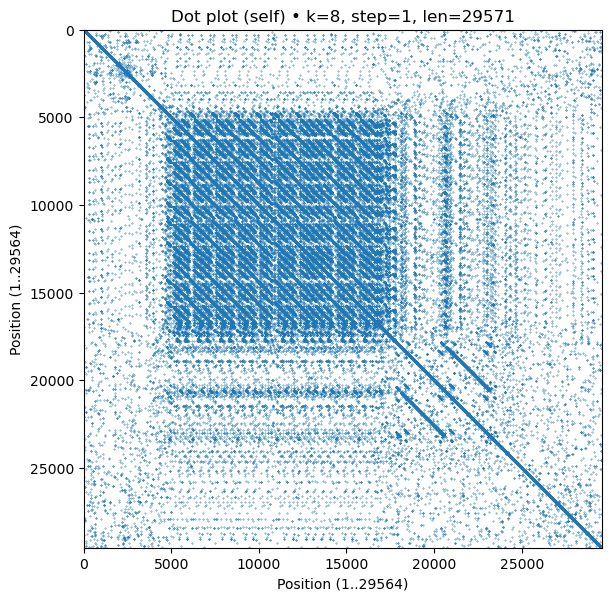

In [759]:
#!/usr/bin/env python3
"""
Dot-plot for a single sequence in a FASTA file (self vs self).

Usage example:
    dotplot_fasta("genome.fa", k=3, step=1, max_len=50000, out="dotplot.png")
"""

from pathlib import Path
from itertools import product
import matplotlib.pyplot as plt

def _read_first_fasta_sequence(path):
    seq = []
    with open(path, "r") as fh:
        for line in fh:
            if line.startswith(">"):
                if seq:  # stop after the first record
                    break
                continue
            seq.append(line.strip())
    if not seq:
        raise ValueError("No sequence found in FASTA.")
    return "".join(seq).upper()[:]

def dotplot_fasta(
    fasta_path: str,
    k: int = 1,
    step: int = 1,
    max_len: int | None = None,
    out: str | None = None,
    dpi: int = 300,
    point_size: float = 0.1,
    title: str | None = None,
):
    """
    Build a self dot-plot of the first sequence in `fasta_path`.

    Parameters
    ----------
    fasta_path : str
        Path to FASTA file (first record is used).
    k : int, default 1
        Word size (k-mer). k=1 reproduces the classic per-base dotplot;
        k>=2 reduces noise and speeds up.
    step : int, default 1
        Slide the k-mer window by this step. Increase to subsample for speed.
    max_len : int | None
        If provided, truncate the sequence to this length (from 5' end).
    out : str | None
        If provided, save figure to this path (PNG/SVG/PDF, etc.).
    dpi : int
        DPI for saving.
    point_size : float
        Marker size for scatter plot.
    title : str | None
        Optional plot title.
    """
    seq = _read_first_fasta_sequence(fasta_path)
    if max_len is not None:
        seq = seq[:max_len]

    n = len(seq)
    if n < k or k < 1:
        raise ValueError("Sequence shorter than k, or invalid k.")

    # Build k-mer index: kmer -> list of positions
    idx = {}
    # keep only unambiguous kmers unless you want Ns included
    for i in range(0, n - k + 1, step):
        kmer = seq[i:i+k]
        if "N" in kmer:  # skip ambiguous by default
            continue
        idx.setdefault(kmer, []).append(i)

    # Build dot coordinates by pairing positions of identical k-mers
    xs, ys = [], []
    append_x, append_y = xs.append, ys.append
    for pos_list in idx.values():
        if len(pos_list) < 2:
            # still need self-diagonal dots; include i==j
            for i in pos_list:
                append_x(i)
                append_y(i)
            continue
        # Cartesian product of positions (including diagonal)
        for i, j in product(pos_list, repeat=2):
            append_x(i)
            append_y(j)

    if not xs:
        raise RuntimeError("No points to plot (sequence may be too short or heavily ambiguous).")

    # Plot
    fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
    ax.scatter(xs, ys, s=point_size)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"Position (1..{n-k+1})")
    ax.set_ylabel(f"Position (1..{n-k+1})")
    ax.set_title(title or f"Dot plot (self) • k={k}, step={step}, len={n}")
    ax.invert_yaxis()  # conventional dot plot orientation (origin at top-left)
    ax.set_xlim(0, n - k + 1)
    ax.set_ylim(n - k + 1, 0)
    # light grid for orientation
    ax.grid(alpha=0.2, linestyle=":")

    if out:
        Path(out).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out, dpi=dpi, bbox_inches="tight")
    return fig, ax


k =  8
dotplot_fasta("../data/interesting_region_CP064967.1.fasta", k=k, out="dotplot.png")



In [266]:
sequence  = _read_first_fasta_sequence("../data/interesting_region_NZ_CP090369.1.fasta")

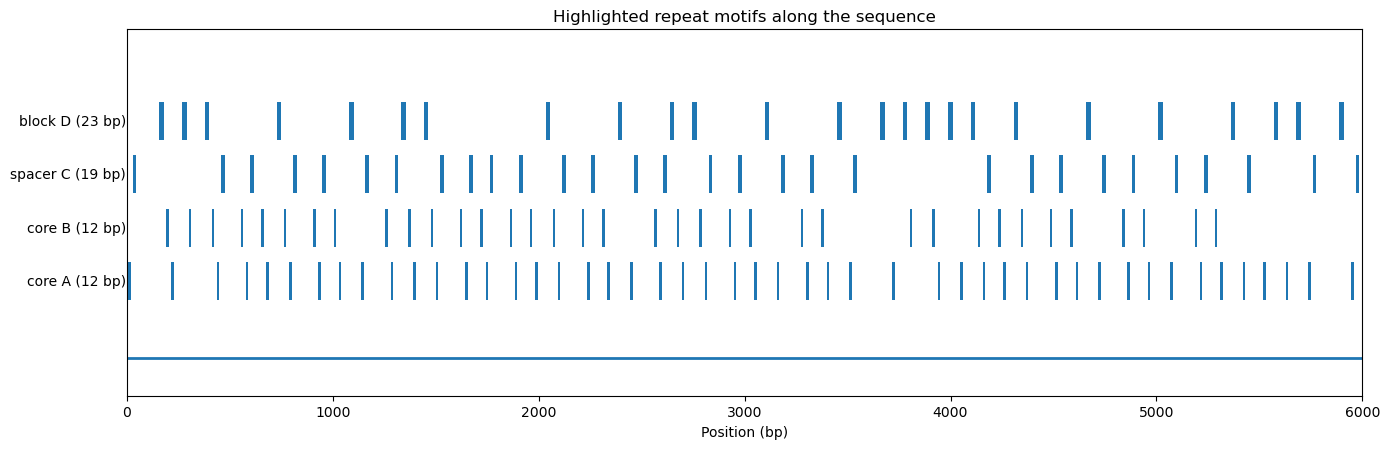

In [273]:
# Visualize and tabulate repeat motifs along the provided sequence
import re
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
# from ace_tools import display_dataframe_to_user

# sequence = ("CATATCCGGAACCTTACTATAGCAGCCGTACTCTTTGCAGATCGTTGTCCCTGCAGCTCGGTGATCTATGATCAGAACATTGCCAGGTGTAGCAGTTATCATGTCCGGAACCTATCTATAACAGCCGTACTCTTTGCTAAACGACATTCCTGCAGCTCGGTGATCAGTTGGAGGGCTATGATTGGAACATTCCCGGATGTAGCAGCTATCATGTCCGGAACCTTACTATAACAGTCATACTCTTTGCTAAACGACATTCCTGCAGCTCGGTGATCAGTTGGAGGGCTATGATTGGAACATTCCCGGATGTAGCAGCTATCATGTCCGGAACCTATCTATAACAGCCGTACTCTTTGCTAAACGACATTCCTGCAGCTCGGTGATCAGTTGGAGGGCTATGATTGGAACATTCCCGGATGTAGCAGCTATCATGTCCGGAACCTTACTATAGCAGTCATACTCTTTGCAGATCGTTGTTCCTGCAGCTGGATAATCGGTTAAATAGTACCCAATATTTTACTCCAACGCTTACCGATCCTTTGCAATGGATATTCCCGGATGTAGCAGCTCTCACATCCAGAACCTTACTATAGCAGCCGTACTCTTTGCAGATCGTTGTCCCTGCAGCTCGGTGATCTATGATCGGAACATTCCCGGATGTAGCAGCTCTCACGTTCAGAACCTTACTATAACAGTCATACTCTTTGCTAAACGACATTCCTGCAGCTCGGTGATCAGTTGGAGGGCTATGATTGGAACATTCCCGGATGTAGCAGCTATCATGTCCAGAACCTTACTATAGCAGTCATACTCTTTGCAGATCGTTGTTCCTGCAGCTGGATAATCGGTTAAATAGTACCCAATATTTTACTCCAACGCTTACCGATCCTTTGCAATGGATATTCCCGGATGTAGCAGCTCTCACATCCAGAACCTTACTATAGCAGCCGTACTCTTTGCAGATCGTTGTCCCTGCAGCTCGGTGATCTATGATCGGAACATTGCCGGATGTAGCAGCTCTCACGTTCAGAACCTTACTATAACAGTCATACTCTTTGCTAAACGACATTCCTGCAGCTGGGTGATCAGTTGGAGGGCTATGATCGGAACATTGCCGGATGTAACAGCTATCATGTCCGGAACCTTACTATAGCAGTCATACTCTTTGCAGATCGTTGTTCCTGCAGCTGGATAATCGGTTAAATAGTACCCAATATTTTACTCCAACGCTTACCGATCCTTTGCAATGGATATTCCCGGATGTAGCAGCTCTCACATCCAGAACCTTACTATAGCAGCCGTACTCTTTGCAGATCGTTGTCCCTGCAGCTCGGTGATCTATGATCGGAACATTGCCGGATGTAGCAGCTCTCACGTTCAGAACCTTACTATAACAGTCATACTCTTTGCTAAACGACATTCCTGCAGCTGGGTGATCAGTTGGAGGGCTATGATTGGAACATTCCCGGATGTAGCAGCTATCATGTCCGGAACCTTACTATAGCAGTCATACTCTTTGCAGATCGTTGTTCCTGCAGCTGGATAATCGGTTAAATAGTACCCAATATTTTACTCCAACGCTTACCGATCCTTTGCAATGGATATTCCCGGATGTAGCAGCTCTCACATCCAGAACCTTACTATAGCAGCCGTACTCTTTGCAGATCGTTGTCCCTGCAGCTCGGTGATCTATGATTGGAACATTCCCGGATGTAGCAGCTATCATGTCCGGAACCTTACTATAGCAGTCATACTCTTTGCAGATCGTTGTTCCTGCAGCTGGATAATCGGTTAAATAGTACCCAATATTTTACTCCAACGCTTACCGATCCTTTGCAATGGATATTCCCGGATGTAGCAGCTCTCACATCCAGAACCTTACTATAGCAGCCGTACTCTTTGCAGATCGTTGTCCCTGCAGCTCGGTGATCTATGATCGGAACATTCCCGGATGTAGCAGCTCTCACGTTCAGAACCTTACTATAACAGTCATACTCTTTGCTAAACGACATTCCTGCAGCTCGGTGATCAGTTGGAGGGCTATGATTGGAACATTGCCGGATGTAGCAGCTATCATGTCCAGAACCTTACTATAGCAGTCATACTCTTTGCAGATCGTTGTTCCTGCAGCTGGATAATCGGTTAAATAGTACCCAATATTTTACTCCAACGCTTACCGATCCTTTGCAATGGATATTCCCGGATGTAGCAGCTCTCACATCCAGAACCTTACTATAGCAGCCGTACTCTTTGCAGATCGTTGTCCCTGCAGCTCGGTGATCTATGATCGGAACATTGCCGGATGTAGCAGCTCTCACGTTCAGAACCTTACTATAACAGTCATACTCTTTGCTAAACGACATTCCTGCAGCTGGGTGATCAGTTGGAGGGCTATGATCGGAACATTGCCGGATGTAACAGCTATCATGTCCGGAACCTTACTATAGCAGTCATACTCTTTGCAGATCGTTGTTCCTGCAGCTGGATAATCGGTTAAATAGTACCCAATATTTTACTCCAACGCTTACCGATCCTTTGCAATGGATATTCCCGGATGTAGCAGCTCTCACATCCAGAACCTTACTATAGCAGCCGTACTCTTTGCAGATCGTTGTCCCTGCAGCTCGGTGATCAGTTGGAGGGCTATGATCGGAACATTGCCGGATGTAGCAGCTCTCACGTTCAGAACCTTACTATAACAGTCATACTCTTTGCTAAACGACATTCCTGCAGCTCGGTGATCAGTTGGAGGGCTATGATTGGAACATTCCCGGATGTAGCAGCTATCATGTCCAGAACCTTACTATAGCAGTCATACTCTTTGCAGATCGTTGTTCCTGCAGCTGGATAATCGGTTAAATAGTACCCAATATTTTACTCCAACGCTTACCGATCCTTTGCAATGGATATTCCCGGATGTAGCAGCTCTCACATCCAGAACCTTACTATAGCAGCCGTACTCTTTGCAGATCGTTGTCCCTGCAGCTCGGTGATCTATGATCGGAACATTGCCGGATGTAGCAGCTCTCACGTTCAGAACCTTACTATAACAGTCATACTCTTTGCTAAACGACATTCCTGCAGCTGGGTGATCAGTTGGAGGGCTATGATCGGAACATTGCCGGATGTAACAGCTATCATGTCCGGAACCTTACTATAGCAGTCATACTCTTTGCAGATCGTTGTTCCTGCAGCTGGATAATCGGTTAAATAGTACCCAATATTTTACTCCAACGCTTACCGATCCTTTGCAATGGATATTCCCGGATGTAGCAGCTCTCACATCCAGAACCTTACTATAGCAGCCGTACTCTTTGCAGATCGTTGTCCCTGCAGCTCGGTGATCTATGATCGGAACATTGCCGGATGTAGCAGCTCTCACGTTCAGAACCTTACTATAACAGTCATACTCTTTGCTAAACGACATTCCTGCAGCTGGGTGATCAGTTGGAGGGCTATGATCGGAACATTGCCGGATGTAACAGCTATCATGTCCGGAACCTTACTATAGCAGCCGTACTCTTTGCAGATCGTTGTCCCTGCAGCTCGGTGATCTATGATCAGAACATTGCCAGGTGTAGCAGCTCTCACGTTCAGAACCTTACTATAACAGCCGTACTCTTTGCTAAACGACATTCCTGTAGCTGGGTGATCAGTTGGAGGGCTATGATCGGAACATTGCCGGATGTAACAGCTATCATGTCCGGAACCTTACTATAACAGTCATACTCTTTGCTAAACGACATTCCTGCAGCTCGGTGATCAGTTGGAGGGCTATGATCGGAACATTGCCGGATGTAACAGCTATCATGTCCGGAACCTTACTATAGCAGCCGTACTCTTTGCAGATCGTTGTCCCTGCAGCTCGGTGATCTATGATCAGAACATTGCCAGGTGTAGCAGTTATCATGTCCGGAACCTATCTATAACAGCCGTACTCTTTGCTAAACGACATTCCTGCAGCTGGGTGATCAGTTGGAGGGCTATGATCGGAACATTGCCGGATGTAACAGCTATCATGTCCGGAACCTTACTATAACAGTCATACTCTTTGCTAAACGACATTCCTGCAGCTCGGTGATCAGTTGGAGGGCTATGATTGGAACATTCCCGGATGTAGCAGCTATCATGTCCGGAACCTATCTATAACAGCCGTACTCTTTGCTAAACGACATTCCTGCAGCTCGGTGATCAGTTGGAGGGCTATGATTGGAACATTCCCGGATGTAGCAGCTCTCACGTTCAGAACCTTACTATAACAGCCGTACTCTTTGCTAAACGACATTCCTGTAGCTGGGTGATCAGTTGGAGGGCTATGATCGGAACATTGCCGGATGTAACAGCTATCATGTCCGGAACCTTACTATAACAGTCATACTCTTTGCTAAACGACATTCCTGCAGCTCGGTGATCAGTTGGAGGGCTATGATTGGAACATTCCCGGATGTAGCAGCTATCATGTCCGGAACCTTACTATAGCAGTCATACTCTTTGCAGATCGTTGTCCCTGCAGCTCGGTGATCTATGATCGGAACATTGCCGGATGTAGCAGCTCTCACGTTCAGAACCTTACTATAACAGTCATACTCTTTGCTAAACGACATTCCTGCAGCTCGGTGATCAGTTGGAGGGCTATGATTGGAACATTCCCGGATGTAGCAGCTATCATGTCCAGAACCTTACTATAGCAGTCATACTCTTTGCAGATCGTTGTTCCTGCAGCTGGATAATCGGTTAAATAGTACCCAATATTTTACTCCAACGCTTACCGATCCTTTGCAATGGATATTCCCGGATGTAGCAGCTCTCACATCCAGAACCTTACTATAGCAGCCGTACTCTTTGCAGATCGTTGTCCCTGCAGCTCGGTGATCTATGATCGGAACATTGCCGGATGTAGCAGCTCTCACGTTCAGAACCTTACTATAACAGTCATACTCTTTGCTAAACGACATTCCTGCAGCTGGGTGATCAGTTGGAGGGCTATGATCGGAACATTGCCGGATGTAACAGCTATCATGTCCGGAACCTTACTATAGCAGTCATACTCTTTGCAGATCGTTGTTCCTGCAGCTGGATAATCGGTTAAATAGTACCCAATATTTTACTCCAACGCTTACCGATCCTTTGCAATGGATATTCCCGGATGTAGCAGCTCTCACATCCAGAACCTTACTATAGCAGCCGTACTCTTTGCAGATCGTTGTCCCTGCAGCTCGGTGATCTATGATCGGAACATTGCCGGATGTAGCAGCTCTCACGTTCAGAACCTTACTATAACAGTCATACTCTTTGCTAAACGACATTCCTGCAGCTGGGTGATCAGTTGGAGGGCTATGATCGGAACATTGCCGGATGTAACAGCTATCATGTCCGGAACCTTACTATAGCAGCCGTACTCTTTGCAGATCGTTGTCCCTGCAGCTCGGTGATCTATGATCAGAACATTGCCAGGTGTAGCAGCTCTCACGTTCAGAACCTTACTATAACAGCCGTACTCTTTGCTAAACGACATTCCTGTAGCTGGGTGATCAGTTGGAGGGCTATGATCGGAACATTGCCGGATGTAACAGCTATCATGTCCGGAACCTTACTATAACAGTCATACTCTTTGCTAAACGACATTCCTGCAGCTCGGTGATCAGTTGGAGGGCTATGATCGGAACATTGCCGGATGTAACAGCTATCATGTCCGGAACCTTACTATAGCAGCCGTACTCTTTGCAGATCGTTGTCCCTGCAGCTCGGTGATCTATGATCAGAACATTGCCAGGTGTAGCAGTTATCATGTCCGGAACCTATCTATAACAGCCGTACTCTTTGCTAAACGACATTCCTGCAGCTCGGTGATCAGTTGGAGGGCTATGATCGGAACATTGCCGGATGTAACAGCTCTCATGTCCGGAACCTTACTATAGCAGTCATACTCTTTGCAGATCGTTGTTCCTGCAGCTGGA")

# Representative repeat motifs to track
motifs = [
    ("GAACCTTACTAT", "core A (12 bp)"),
    ("CCGGATGTAGCA", "core B (12 bp)"),
    ("TACTCTTTGCAGATCGTT", "spacer C (19 bp)"),
    ("GGTGATCAGTTGGAGGGCTATG", "block D (23 bp)"),
]

# Find all occurrences
records = []
tracks = defaultdict(list)

for motif, label in motifs:
    for m in re.finditer(re.escape(motif), sequence):
        start = m.start()
        end = m.end()
        records.append({"motif": label, "start": start, "end": end, "length": len(motif), "sequence": motif})
        tracks[label].append((start, len(motif)))

# Tabulate
df = pd.DataFrame(records).sort_values(["motif", "start"]).reset_index(drop=True)
# display_dataframe_to_user("Repeat motif positions", df)

# Plot a linear map: one horizontal track per motif
fig, ax = plt.subplots(figsize=(14, 3 + 0.4 * len(motifs)))

# Draw the sequence backbone
ax.hlines(y=0, xmin=0, xmax=len(sequence), linewidth=2)

# Draw tracks
y_base = 1.0
y_step = 0.7

for i, (motif, label) in enumerate(motifs):
    y = y_base + i * y_step
    ax.text(-5, y, label, ha="right", va="center")
    # draw each occurrence as a rectangle
    for start, width in tracks[label]:
        rect = Rectangle((start, y - 0.25), width, 0.5, fill=True)
        ax.add_patch(rect)

# Aesthetics
ax.set_ylim(-0.5, y_base + len(motifs) * y_step + 0.5)
ax.set_xlim(0, len(sequence))
ax.set_xlabel("Position (bp)")
ax.set_yticks([])
ax.set_title("Highlighted repeat motifs along the sequence")

plt.tight_layout()
plt.show()
